In [1]:
import pandas as pd
import glob
import os

# Path to all CSV files in the datasets folder
data_path = r"C:\Users\natet\EnbridgeProject\data\Wind Farm A\datasets\*.csv"
all_files = glob.glob(data_path)

print(f"Found {len(all_files)} CSV files")

# Load and combine all files
dfs = []
for f in all_files:
    df_temp = pd.read_csv(f, sep=';')
    dfs.append(df_temp)

df_all = pd.concat(dfs, ignore_index=True)
print(f"Total rows loaded: {len(df_all)}")
print(f"\nstatus_type_id distribution across all files:")
print(df_all['status_type_id'].value_counts())
print(f"\nAsset IDs present: {sorted(df_all['asset_id'].unique())}")

Found 22 CSV files
Total rows loaded: 1196747

status_type_id distribution across all files:
status_type_id
0    1053736
4     119322
3      23689
Name: count, dtype: int64

Asset IDs present: [np.int64(0), np.int64(10), np.int64(11), np.int64(13), np.int64(21)]


In [2]:
# Keep only unambiguous statuses
df_clean = df_all[df_all['status_type_id'].isin([0, 2, 4])].copy()

# Correct labels
df_clean['label'] = df_clean['status_type_id'].apply(lambda x: 1 if x == 4 else 0)

print("Label distribution:")
print(df_clean['label'].value_counts())
print(f"\nNormal (status 0+2): {(df_clean['label']==0).sum()}")
print(f"Anomaly (status 4):  {(df_clean['label']==1).sum()}")
print(f"Imbalance ratio: {(df_clean['label']==1).sum() / (df_clean['label']==0).sum():.1f}:1")
print(f"\nRows excluded (status 1,3,5): {len(df_all[df_all['status_type_id'].isin([1,3,5])])}")

Label distribution:
label
0    1053736
1     119322
Name: count, dtype: int64

Normal (status 0+2): 1053736
Anomaly (status 4):  119322
Imbalance ratio: 0.1:1

Rows excluded (status 1,3,5): 23689


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import time

X = df_clean.drop(columns=['time_stamp', 'asset_id', 'id', 'train_test', 'status_type_id', 'label'])
y = df_clean['label']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training rows:  {len(X_train)}")
print(f"Test rows:      {len(X_test)}")
print(f"Training label counts:\n{y_train.value_counts()}")

# Train
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

print("\nTraining... (may take a few minutes on 1M rows)")
start = time.time()
rf.fit(X_train, y_train)
print(f"Done in {time.time() - start:.1f}s")


Training rows:  938446
Test rows:      234612
Training label counts:
label
0    842988
1     95458
Name: count, dtype: int64

Training... (may take a few minutes on 1M rows)
Done in 151.1s


              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00    210748
     Anomaly       0.99      0.95      0.97     23864

    accuracy                           0.99    234612
   macro avg       0.99      0.98      0.98    234612
weighted avg       0.99      0.99      0.99    234612



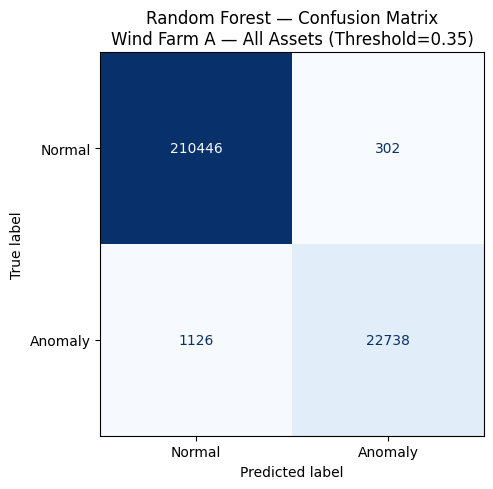

In [5]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get anomaly probabilities and apply threshold
proba = rf.predict_proba(X_test)[:, 1]
y_pred = (proba >= 0.35).astype(int)

print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomaly']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Random Forest — Confusion Matrix\nWind Farm A — All Assets (Threshold=0.35)')
plt.tight_layout()
plt.show()

Top 20 most important sensors:
      feature  importance
sensor_41_avg    0.058573
 sensor_0_avg    0.057625
sensor_53_avg    0.049087
 sensor_6_avg    0.032709
sensor_42_avg    0.032489
sensor_40_avg    0.032326
sensor_43_avg    0.026747
sensor_13_avg    0.026150
sensor_39_avg    0.023986
sensor_38_avg    0.023260
 sensor_8_avg    0.022244
sensor_14_avg    0.021726
 sensor_1_avg    0.020293
sensor_12_avg    0.019453
sensor_19_avg    0.019295
sensor_17_avg    0.018911
sensor_11_avg    0.018380
sensor_36_avg    0.016692
sensor_15_avg    0.016446
 sensor_9_avg    0.015823


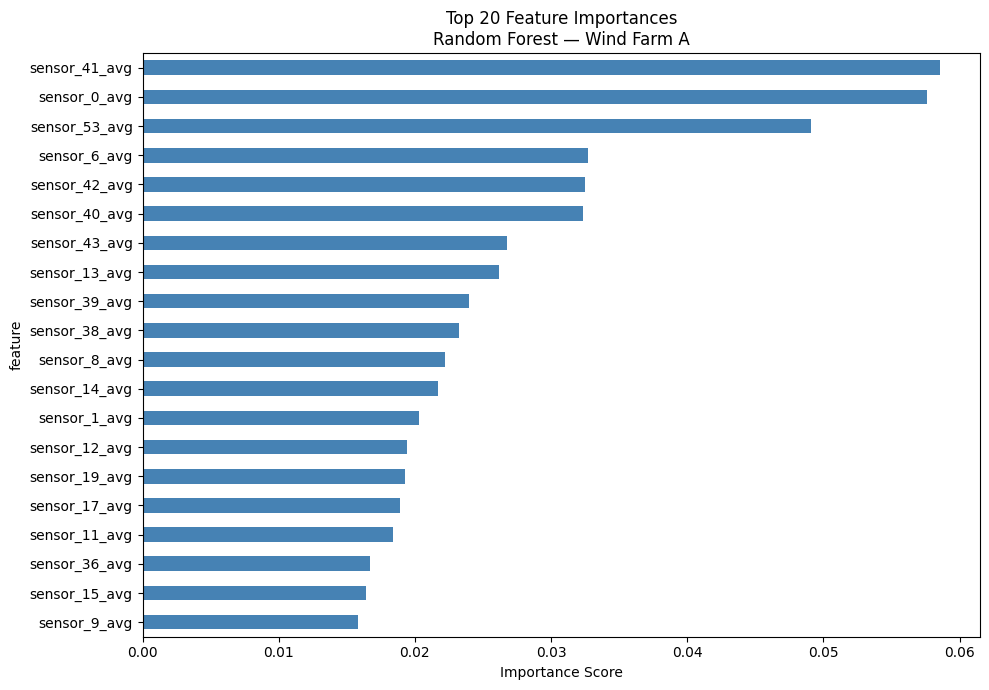

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Build importance dataframe
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 most important sensors:")
print(importances.head(20).to_string(index=False))

# Plot top 20
fig, ax = plt.subplots(figsize=(10, 7))
importances.head(20).plot.barh(x='feature', y='importance', ax=ax, legend=False, color='steelblue')
ax.invert_yaxis()
ax.set_xlabel('Importance Score')
ax.set_title('Top 20 Feature Importances\nRandom Forest — Wind Farm A')
plt.tight_layout()
plt.show()

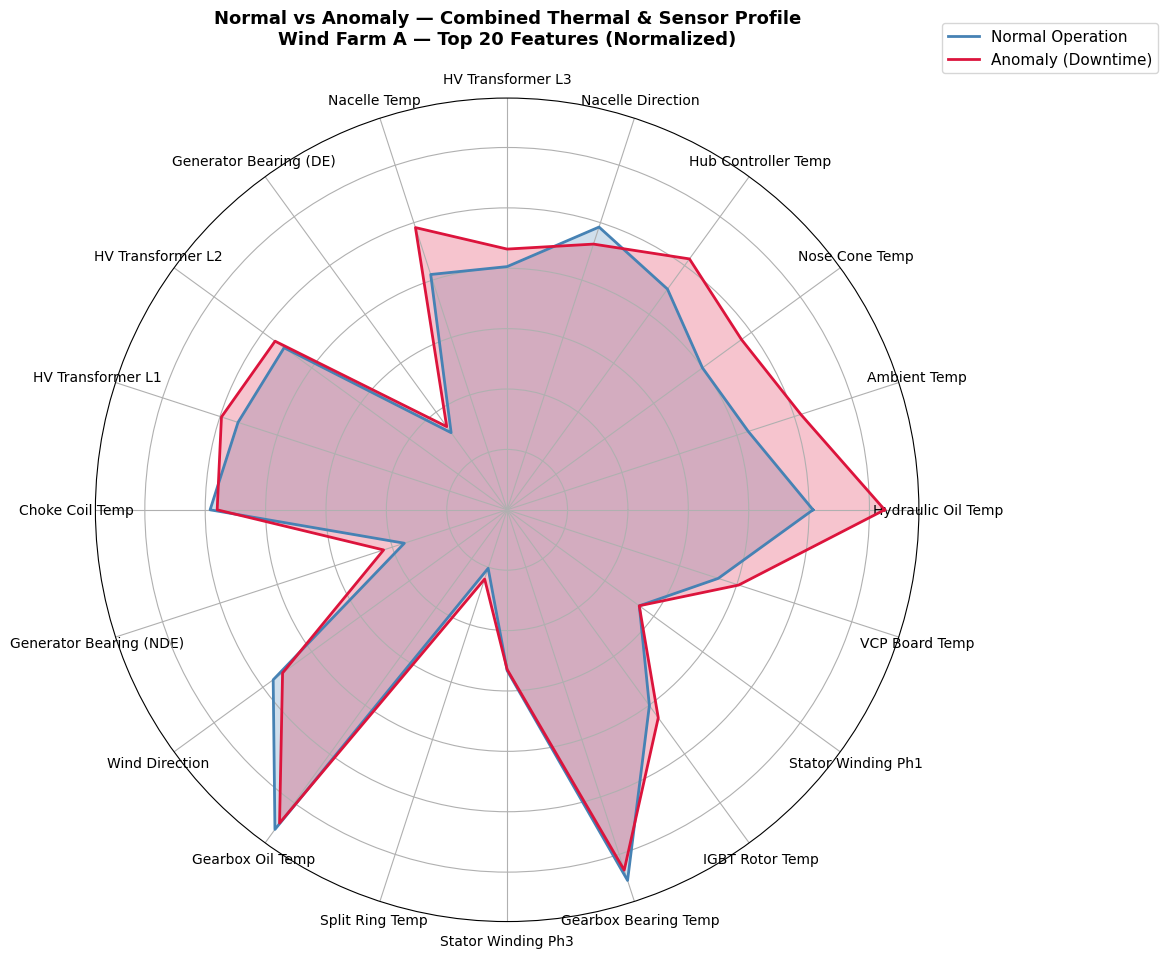

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

# Top 20 features
top20 = [
    'sensor_41_avg', 'sensor_0_avg', 'sensor_53_avg', 'sensor_6_avg',
    'sensor_42_avg', 'sensor_40_avg', 'sensor_43_avg', 'sensor_13_avg',
    'sensor_39_avg', 'sensor_38_avg', 'sensor_8_avg', 'sensor_14_avg',
    'sensor_1_avg', 'sensor_12_avg', 'sensor_19_avg', 'sensor_17_avg',
    'sensor_11_avg', 'sensor_36_avg', 'sensor_15_avg', 'sensor_9_avg'
]

# Friendly labels
labels = [
    'Hydraulic Oil Temp', 'Ambient Temp', 'Nose Cone Temp', 'Hub Controller Temp',
    'Nacelle Direction', 'HV Transformer L3', 'Nacelle Temp', 'Generator Bearing (DE)',
    'HV Transformer L2', 'HV Transformer L1', 'Choke Coil Temp', 'Generator Bearing (NDE)',
    'Wind Direction', 'Gearbox Oil Temp', 'Split Ring Temp', 'Stator Winding Ph3',
    'Gearbox Bearing Temp', 'IGBT Rotor Temp', 'Stator Winding Ph1', 'VCP Board Temp'
]

# Separate normal and anomaly
normal = df_clean[df_clean['label'] == 0][top20]
anomaly = df_clean[df_clean['label'] == 1][top20]

# Normalize each feature 0-1 across the combined dataset so they're comparable
combined = df_clean[top20]
norm_min = combined.min()
norm_max = combined.max()

normal_norm = ((normal.mean() - norm_min) / (norm_max - norm_min)).values
anomaly_norm = ((anomaly.mean() - norm_min) / (norm_max - norm_min)).values

# Radar setup
N = len(top20)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

normal_norm = np.append(normal_norm, normal_norm[0])
anomaly_norm = np.append(anomaly_norm, anomaly_norm[0])

fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(polar=True))

# Plot
ax.plot(angles, normal_norm, color='steelblue', linewidth=2, label='Normal Operation')
ax.fill(angles, normal_norm, color='steelblue', alpha=0.25)

ax.plot(angles, anomaly_norm, color='crimson', linewidth=2, label='Anomaly (Downtime)')
ax.fill(angles, anomaly_norm, color='crimson', alpha=0.25)

# Labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, size=10)
ax.set_yticklabels([])
ax.set_title('Normal vs Anomaly — Combined Thermal & Sensor Profile\nWind Farm A — Top 20 Features (Normalized)',
             size=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)

plt.tight_layout()
plt.show()